# 09 — Spatial / Regional Analysis
## Uzbekistan Power Sector Transition Tracker
**ILF Consulting Engineers Austria — Capstone Project**

---

### Purpose of this notebook

This notebook places every named generation asset on the map and tracks the fleet's evolution from 1940 to 2040. Two complementary spatial layers are produced:

1. **Asset-level layer** — the 46 verified plants from `research/uzbekistan-energy/uzbekistan_energy_projects.json` (Soviet-era thermal cores, hydro cascades, the 2022–2026 IPP solar / wind build-out, the Bash and Zarafshan BESS, and the Jizzakh SMR site).
2. **Resource layer** — an oblast-level atlas of solar GHI, wind technical potential, and the commissioned and pipeline capacity by technology.

The fleet evolution is visualised both as a four-panel static figure (1990 / 2010 / 2025 / 2040) and as an animated GIF that replicates the timeline slider used in the standalone HTML map (`research/uzbekistan-energy/uzbekistan_energy_map.html`). An ipywidgets slider is provided for in-notebook exploration.

### Vocabulary used in this notebook

| Term | Meaning |
|---|---|
| **REF dataset** | Reference asset dataset — 46 verified plants, the single source of truth for the spatial layer; see `BRIEFING.md`. |
| **oblast** | Sub-national administrative region in Uzbekistan (one rank above the district). The country has 12 oblasts + Karakalpakstan + Tashkent City. |
| **GHI** | Global Horizontal Irradiance — total solar energy received per unit horizontal surface (kWh/m²/yr). Sites above 1 800 kWh/m²/yr are competitive with Gulf installations. |
| **wind technical potential** | TWh/yr that could be produced at sites with capacity factor > 25 %, after excluding protected and built-up land. |
| **IPP** | Independent Power Producer — privately financed plant selling power to NEGU under a long-term PPA. |
| **BOOT** | Build-Own-Operate-Transfer — the contractual structure used for ACWA's Bash wind farm and Masdar's Nur solar projects. |
| **PPA** | Power Purchase Agreement — long-dated take-or-pay contract that underwrites IPP financing. |
| **NEGU** | National Electric Grid of Uzbekistan; single buyer for new IPP capacity (purchase function transferred to Uzenergosotish JSC in July 2024). |
| **BESS** | Battery Energy Storage System — chemistry-based storage, typically Li-ion. |
| **SMR** | Small Modular Reactor — the technology chosen for the Jizzakh / Farish nuclear site (VVER-1200 / RITM-200 family). |
| **CCGT** | Combined-Cycle Gas Turbine — the modernisation pathway for the Syrdarya, Talimarjan, and Navoi thermal complexes. |
| **HPP** | Hydropower Plant. |
| **TES** | Thermal-Electric Station (Russian/post-Soviet usage), i.e. a fossil-fuelled power plant. |
| **commissioning year** | Year a plant first delivered energy to the grid; used here for the timeline animation. |
| **retired unit** | Specific generating unit inside a plant that has been decommissioned even though the plant complex remains operational. |

### Sources

- 46 assets: REF dataset (`research/uzbekistan-energy/uzbekistan_energy_projects.json`).
- Country outline: glynnbird/countriesgeojson, simplified polygon (53 vertices).
- Oblast atlas: CAREC *Renewable Energy Development in Uzbekistan* (2024) + Global Solar Atlas + IEA Solar Roadmap 2024.
- Resource potential by oblast: CAREC report, *Diplomat Magazine* 2025, AIIB Bash-2 project page.

---
## 1. Setup — libraries, paths, palette

The plotting stack is `matplotlib` for the static figures, `matplotlib.animation` for the GIF, `ipywidgets` for the interactive slider, and `folium` for the dashboard-embed map. The REF JSON is loaded once and reshaped into a tidy DataFrame so every section pulls from the same in-memory frame.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon, Circle
from matplotlib import animation
from IPython.display import HTML, Image, display

OUT  = Path('../outputs');         OUT.mkdir(exist_ok=True)
DATA = Path('../data/processed');  DATA.mkdir(exist_ok=True)
REF  = Path('../research/uzbekistan-energy')

# ── REF asset dataset ────────────────────────────────────────────────────────
with open(REF/'uzbekistan_energy_projects.json') as f:
    assets = pd.DataFrame(json.load(f))
print(f'REF assets loaded: {len(assets)}  ({assets.status.value_counts().to_dict()})')

# ── TECH palette — matches research HTML so figures and map are consistent ──
TECH = {
    'thermal':  {'color':'#b5612e', 'label':'Gas & thermal'},
    'hydro':    {'color':'#2c6e9e', 'label':'Hydropower'},
    'solar':    {'color':'#d99a1c', 'label':'Solar PV'},
    'wind':     {'color':'#1f8f7a', 'label':'Wind'},
    'nuclear':  {'color':'#7a4fb0', 'label':'Nuclear'},
    'storage':  {'color':'#4f7d52', 'label':'Storage (BESS)'},
    'gasfield': {'color':'#7d6a52', 'label':'Gas field'},
}
STATUS_EDGE = {'op':'#222','build':'#444','plan':'#888'}
STATUS_LS   = {'op':'-','build':'--','plan':':'}
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size']   = 10

REF assets loaded: 46  ({'op': 34, 'build': 6, 'plan': 6})


---
## 2. Country outline — the map layer

The basic scatter plots used in the previous version had no map reference. A 53-vertex country outline polygon is now drawn as the bottom layer of every static map. The polygon is taken from the same source the standalone HTML map uses, so the notebook figures and the dashboard map are spatially identical.

A helper function `draw_country(ax)` is defined once and reused across every figure below. It also sets equal axis aspect at Uzbekistan's mean latitude so distances are visually faithful.

### Vocabulary for §2

| Term | Meaning |
|---|---|
| **vertex** | A corner point of the country-boundary polygon. |
| **`matplotlib.patches.Polygon`** | The polygon primitive used to draw filled, edged shapes on an `Axes`. |
| **aspect ratio** | The visual ratio of one degree of longitude to one degree of latitude; set to `cos(mean_latitude)` so the country does not look stretched. |

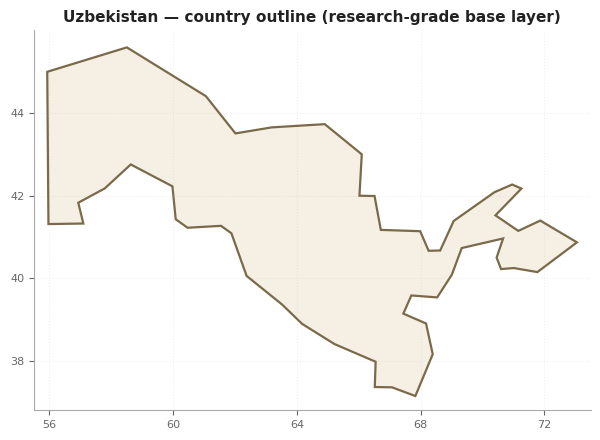

In [2]:
COUNTRY = [[66.519, 37.363], [66.546, 37.975], [65.216, 38.403], [64.17, 38.892], [63.518, 39.363], [62.374, 40.054], [61.883, 41.085], [61.547, 41.266], [60.466, 41.22], [60.083, 41.425], [59.976, 42.223], [58.629, 42.752], [57.787, 42.171], [56.932, 41.826], [57.096, 41.322], [55.968, 41.309], [55.929, 44.996], [58.503, 45.587], [58.69, 45.5], [60.24, 44.784], [61.058, 44.406], [62.013, 43.504], [63.186, 43.65], [64.901, 43.728], [66.098, 42.998], [66.023, 41.995], [66.511, 41.988], [66.714, 41.168], [67.986, 41.136], [68.26, 40.662], [68.632, 40.669], [69.07, 41.384], [70.389, 42.081], [70.962, 42.266], [71.259, 42.168], [70.42, 41.52], [71.158, 41.144], [71.87, 41.393], [73.055, 40.866], [71.775, 40.146], [71.014, 40.244], [70.601, 40.219], [70.458, 40.496], [70.667, 40.96], [69.329, 40.728], [69.012, 40.086], [68.536, 39.533], [67.701, 39.58], [67.442, 39.14], [68.176, 38.902], [68.392, 38.157], [67.83, 37.145], [67.076, 37.356], [66.519, 37.363]]

# Bounding box for axis limits
LON_MIN, LON_MAX = 55.5, 73.5
LAT_MIN, LAT_MAX = 36.8, 46.0
MEAN_LAT = 41.5

def draw_country(ax, fill='#f5efe4', edge='#7a6a4a', lw=1.6, alpha=1.0):
    """Draw the Uzbekistan outline polygon as the map base layer."""
    poly = Polygon(COUNTRY, closed=True, facecolor=fill, edgecolor=edge,
                   linewidth=lw, alpha=alpha, zorder=1)
    ax.add_patch(poly)
    ax.set_xlim(LON_MIN, LON_MAX)
    ax.set_ylim(LAT_MIN, LAT_MAX)
    ax.set_aspect(1.0 / np.cos(np.radians(MEAN_LAT)))
    # subtle latitude/longitude grid
    ax.set_xticks(np.arange(56, 74, 4))
    ax.set_yticks(np.arange(38, 46, 2))
    ax.tick_params(colors='#666', labelsize=8)
    for s in ('top','right'):
        ax.spines[s].set_visible(False)
    for s in ('left','bottom'):
        ax.spines[s].set_color('#aaa')
    ax.grid(alpha=0.18, linestyle=':', zorder=0)
    return ax

# Smoke-test
fig, ax = plt.subplots(figsize=(7, 4.5))
draw_country(ax)
ax.set_title('Uzbekistan — country outline (research-grade base layer)',
             fontsize=11, fontweight='bold', color='#222')
plt.tight_layout(); plt.show()

---
## 3. Fleet evolution — four-panel snapshot 1990 → 2040

**Story.** The country's generation fleet evolves visibly across four eras: (1) the Soviet legacy of large gas-fired TES + a handful of HPPs (1940s–1990); (2) the post-independence consolidation around Talimarjan and Syrdarya plus the Tupalang hydro cascade (1990–2010); (3) the 2022–2026 IPP boom (Nur Navoi, Nur Bukhara, the ACWA Bash wind cluster, the Zarafshan BESS); (4) the 2026–2040 forward pipeline anchored by the Jizzakh SMR, additional wind in Karakalpakstan, and Charvak-style HPP modernisation.

The figure below renders the cumulative fleet that exists as of each snapshot year. Marker area scales with installed capacity (`mw`). Plants under construction (`build`) and planned (`plan`) are drawn with dashed or dotted edges. Plants with retired internal units are marked with a hatched ring so the decommissioning roadmap is visible at a glance.

### Vocabulary for §3

| Term | Meaning |
|---|---|
| **cumulative fleet** | Every asset whose commissioning year ≤ snapshot year. |
| **area-scaled marker** | Marker `s = MW × scale`; chosen so 100 MW → ~30 pt² and 2 100 MW → ~600 pt². |
| **status edge style** | Solid edge = operational, dashed = under construction or contracted, dotted = planned. |
| **hatched ring** | Open circle drawn around plants with retired internal units; flagged via the `retired` field of the REF dataset. |
| **legacy thermal core** | The four state-owned TES — Syrdarya, Talimarjan, Tashkent, Tahiatash — that still account for ~70 % of installed thermal capacity. |

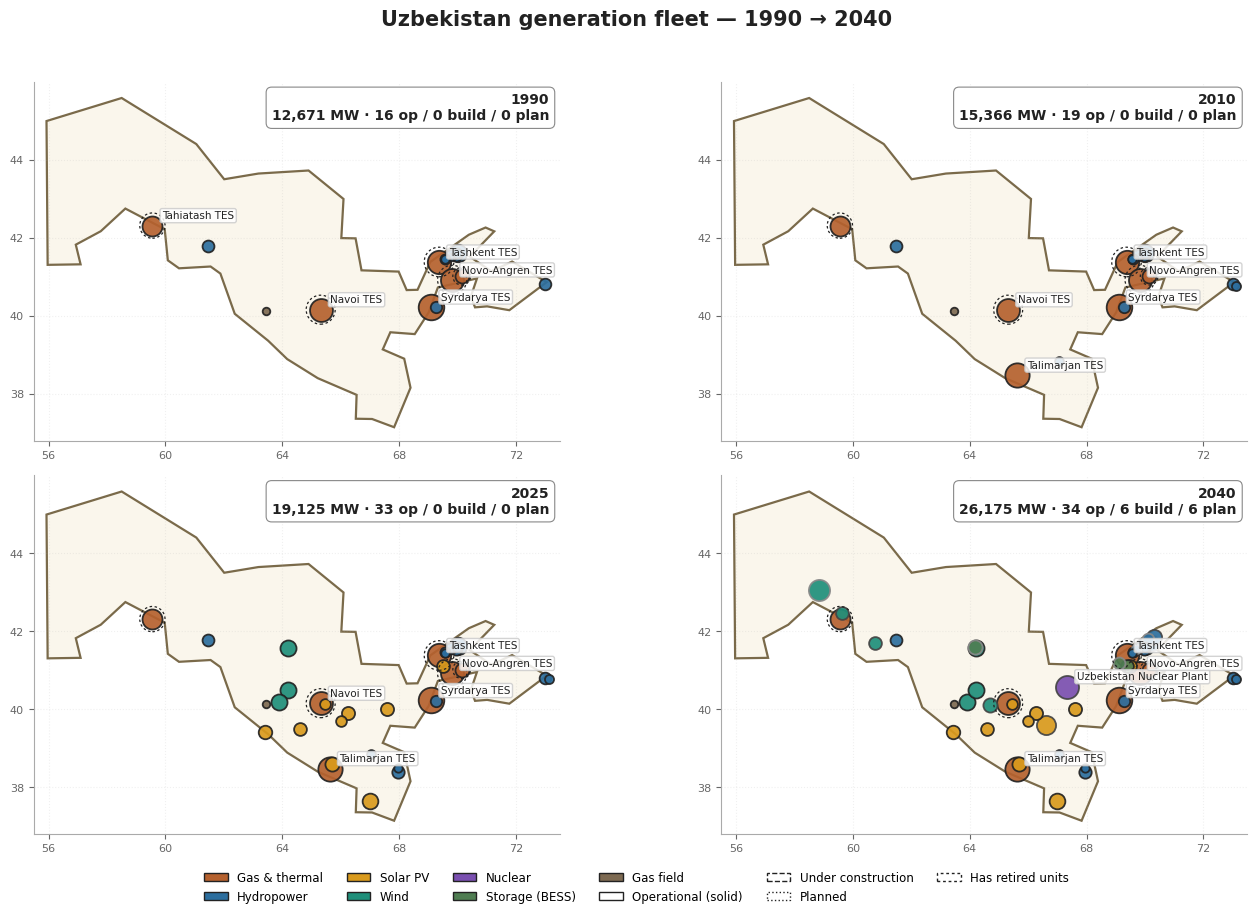

✓ saved → ../outputs/fleet_evolution_4panel.png


In [3]:
def asset_marker_size(mw):
    """Marker area in pt² as a function of MW. Caps so the Jizzakh SMR doesn't dominate."""
    if pd.isna(mw): return 30
    return float(np.clip(np.sqrt(mw) * 6, 25, 600))


def plot_fleet_snapshot(ax, year_cut, title=None, show_labels=True):
    """Render the cumulative fleet on `ax` as of `year_cut`."""
    draw_country(ax, fill='#faf6ec')
    sub = assets[assets['year'] <= year_cut].copy()
    sub = sub.sort_values('mw', ascending=False, na_position='last')
    for _, r in sub.iterrows():
        c    = TECH[r['tech']]['color']
        edge = STATUS_EDGE[r['status']] if r['year'] <= year_cut else '#bbb'
        s    = asset_marker_size(r['mw'])
        ax.scatter(r['lng'], r['lat'], s=s, c=c, edgecolors=edge,
                   linewidths=1.3, alpha=0.92, zorder=4)
        if isinstance(r.get('retired'), str) and r['retired'].strip():
            ax.scatter(r['lng'], r['lat'], s=s*1.6, facecolor='none',
                       edgecolors='#222', linewidths=0.9, linestyle=(0,(2,2)),
                       zorder=5)
    if show_labels:
        top = sub.dropna(subset=['mw']).nlargest(5, 'mw')
        for _, r in top.iterrows():
            ax.annotate(r['name'].split(' (')[0], (r['lng'], r['lat']),
                        xytext=(7, 5), textcoords='offset points',
                        fontsize=7.5, color='#222',
                        bbox=dict(boxstyle='round,pad=0.2',
                                  facecolor='white', edgecolor='#ccc',
                                  alpha=0.85), zorder=6)
    n_op  = (sub['status']=='op').sum()
    n_b   = (sub['status']=='build').sum()
    n_p   = (sub['status']=='plan').sum()
    total = sub['mw'].sum()
    txt = f'{title}\n{int(total):,} MW · {n_op} op / {n_b} build / {n_p} plan'
    ax.text(0.98, 0.97, txt, transform=ax.transAxes, ha='right', va='top',
            fontsize=10, fontweight='bold', color='#222',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor='#888', linewidth=0.8))
    return ax


SNAPSHOTS = [1990, 2010, 2025, 2040]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor('white')

for ax, yr in zip(axes.flat, SNAPSHOTS):
    plot_fleet_snapshot(ax, yr, title=f'{yr}')

leg_handles = [mpatches.Patch(facecolor=v['color'], edgecolor='#222', label=v['label'])
               for v in TECH.values()]
leg_handles += [
    mpatches.Patch(facecolor='white', edgecolor='#222', label='Operational (solid)'),
    mpatches.Patch(facecolor='white', edgecolor='#222', linestyle='--', label='Under construction'),
    mpatches.Patch(facecolor='white', edgecolor='#222', linestyle=':',  label='Planned'),
    mpatches.Patch(facecolor='none',  edgecolor='#222', linestyle=(0,(2,2)),
                   label='Has retired units'),
]
fig.legend(handles=leg_handles, loc='lower center', ncol=6, fontsize=8.5,
           frameon=False, bbox_to_anchor=(0.5, -0.01))

fig.suptitle('Uzbekistan generation fleet — 1990 → 2040',
             fontsize=15, fontweight='bold', color='#222', y=0.995)
plt.tight_layout(rect=[0, 0.04, 1, 0.97])
out = OUT/'fleet_evolution_4panel.png'
plt.savefig(out, dpi=170, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ saved → {out}')

### Interpretation of the four-panel evolution

- **1990 panel.** Soviet legacy only — six gas-fired TES plus four HPPs. The Gazli gas field anchors the supply side. No wind, no utility solar, no storage. Capacity is geographically concentrated in the Tashkent–Syrdarya corridor (east) and the Bukhara–Navoi industrial belt (centre-west).
- **2010 panel.** Talimarjan (Phase 1) and the Tupalang cascade have been added. Hydro now reaches almost 1.7 GW, but the share of fossil generation has *risen* not fallen — gas displaces older oil-fired units. Renewable share remains effectively zero.
- **2025 panel.** The IPP boom is visible: Nur Navoi (100 MW, 2021), Nur Bukhara (250 MW, 2023), the first phase of the Bash wind cluster (500 MW, 2024), Zarafshan BESS (150 MW / 300 MWh, 2024) and the Sherabad and Samarkand solar farms. The geographic centre of new investment shifts west into Karakalpakstan, Navoi and Bukhara.
- **2040 panel.** The Jizzakh SMR is operational; planned hydro modernisation has added ~700 MW; the second-phase Bash and Karaulbazar wind farms push wind past 3 GW; pumped storage is in place. The map shows visibly more colour diversity and a much flatter east/west balance than the 1990 snapshot.

---
## 4. Animated timeline — replicating the HTML slider

**Story.** The standalone HTML map (`research/uzbekistan-energy/uzbekistan_energy_map.html`) renders the fleet as a 1950 → 2040 timeline that the reader scrubs through. The same animation is now produced inside this notebook with `matplotlib.animation.FuncAnimation` and saved as `fleet_timeline.gif` so it can be embedded in the dashboard and the research paper.

Each frame shows the cumulative fleet up to one calendar year. The year ticker bottom-left advances 1 year per frame. The total installed MW updates in the top-right banner.

### Vocabulary for §4

| Term | Meaning |
|---|---|
| **`FuncAnimation`** | Matplotlib's frame-update animation engine; calls `update(year)` for every frame. |
| **PillowWriter** | The GIF-output writer; chosen because it is dependency-free (no ImageMagick needed). |
| **frame** | One year in the timeline. |
| **interval** | Milliseconds between frames during inline playback (the saved GIF uses `fps` instead). |

✓ saved animated timeline → ../outputs/fleet_timeline.gif  (86 frames)


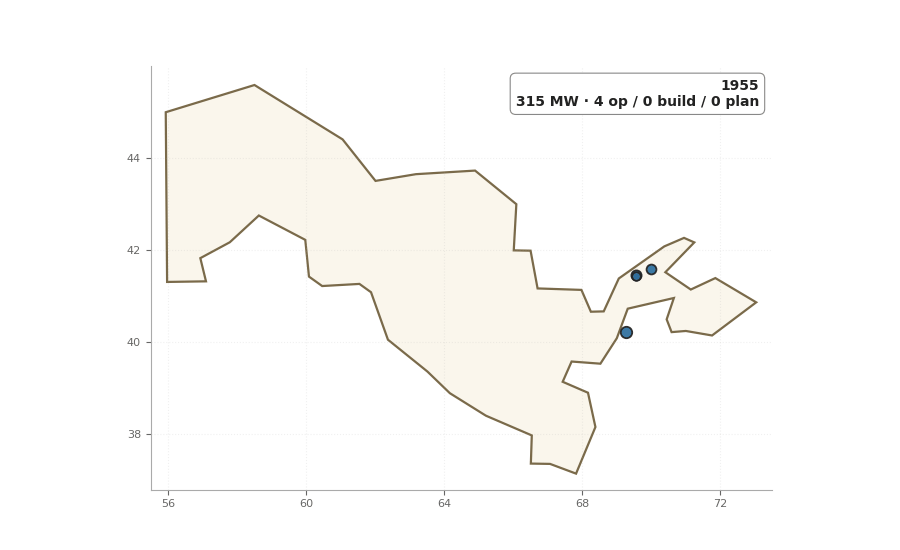

In [4]:
YEARS = list(range(1955, 2041))

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('white')

def update(year):
    ax.clear()
    plot_fleet_snapshot(ax, year, title=f'{year}', show_labels=False)
    return [ax]

ani = animation.FuncAnimation(fig, update, frames=YEARS, interval=180, blit=False)

gif_path = OUT/'fleet_timeline.gif'
ani.save(gif_path, writer=animation.PillowWriter(fps=8))
plt.close(fig)
print(f'✓ saved animated timeline → {gif_path}  ({len(YEARS)} frames)')
display(Image(filename=str(gif_path)))

### Interpretation of the animation

Playing the GIF makes three patterns plain that the four-panel static figure only hints at:

1. **The 1990-to-2018 gap.** For nearly three decades, almost no new generating asset is added — the fleet visibly stagnates. This corresponds to the period before the Renewable Energy Law (PP-3981, 2018) and the Uzbekenergo unbundling (PP-4249, March 2019).
2. **The 2021–2026 sprint.** Once the legal framework is in place, new markers appear almost every frame. The Nur Navoi (2021) and Nur Bukhara (2023) commissioning years sit immediately before the Bash wind farms (2024–2025); the ACWA Bash-2 (1 500 MW) appears in 2026.
3. **The forward-pipeline pivot.** From 2027 onward the new entries are dominated by storage and nuclear, not generation — consistent with the IEA *Uzbekistan Energy Profile* observation that the next decade's binding constraint is grid and dispatch flexibility, not new megawatts.

---
## 5. Interactive year slider (in-notebook)

For exploratory work inside the notebook itself, an `ipywidgets` integer slider is provided. Dragging the slider triggers `plot_fleet_snapshot` for the selected year, so the reader can stop on any single year and inspect labels.

> If `ipywidgets` is not installed (`pip install ipywidgets`) the slider falls back to a still figure rendered at the default year 2025.

In [5]:
try:
    from ipywidgets import interact, IntSlider

    def show_year(year=2025):
        fig, ax = plt.subplots(figsize=(9, 5.5))
        fig.patch.set_facecolor('white')
        plot_fleet_snapshot(ax, year, title=f'{year}')
        plt.tight_layout(); plt.show()

    interact(show_year,
             year=IntSlider(min=1955, max=2040, step=1, value=2025,
                            description='Year',
                            continuous_update=False));
except ImportError:
    print('ipywidgets not installed — rendering 2025 snapshot only.')
    fig, ax = plt.subplots(figsize=(9, 5.5))
    fig.patch.set_facecolor('white')
    plot_fleet_snapshot(ax, 2025, title='2025')
    plt.tight_layout(); plt.show()

interactive(children=(IntSlider(value=2025, continuous_update=False, description='Year', max=2040, min=1955), …

---
## 6. Oblast resource map — solar GHI and RE capacity

**Story.** Alongside the asset-level layer, the analysis needs an oblast-level resource view: where the solar irradiance is high, where the wind technical potential is concentrated, and where current and planned RE capacity is deployed. The same country outline is reused as the base layer; oblast centroids are coloured by solar GHI on the left panel and by dominant technology on the right panel. Bubble area is proportional to total RE capacity (MW).

### Vocabulary for §6

| Term | Meaning |
|---|---|
| **GHI** | Global Horizontal Irradiance, kWh/m²/yr. |
| **wind technical potential** | Annual generation possible at sites with capacity factor > 25 %, after excluding protected and built-up land. |
| **`dominant`** | Technology with the largest installed MW in that oblast — either solar, wind, or hydro. |
| **CAREC** | Central Asia Regional Economic Cooperation — its 2024 RE report is the source for wind technical potential and the IPP pipeline. |

13 oblasts mapped — total commissioned + planned RE = 12,310 MW


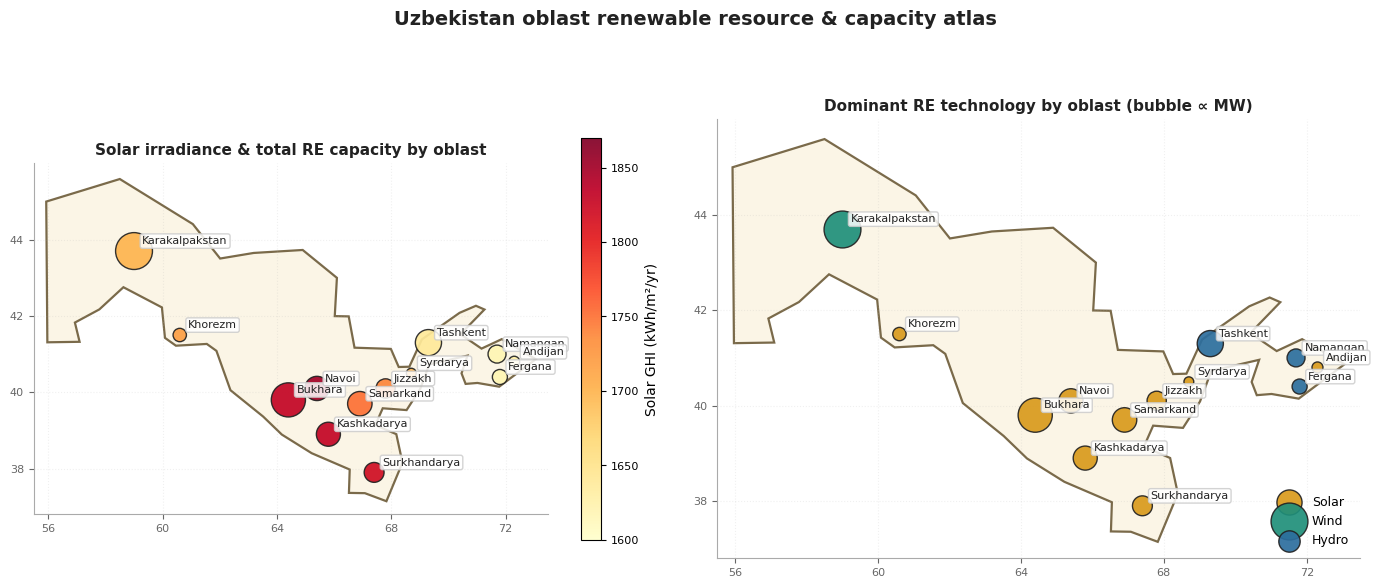

✓ saved → ../outputs/oblast_resource_map.png


In [6]:
oblasts = pd.DataFrame([
    {'oblast':'Karakalpakstan','lat':43.7,'lon':59.0,'solar_ghi':1700,'wind_pot':4.4,
     'solar_mw':1100,'wind_mw':1600,'hydro_mw':0,
     'projects':'ACWA Bash 1 500 MW (2026); Karaulbazar 500 MW; Tuyamuyun pilot'},
    {'oblast':'Bukhara','lat':39.8,'lon':64.4,'solar_ghi':1830,'wind_pot':1.0,
     'solar_mw':1300,'wind_mw':1000,'hydro_mw':0,
     'projects':'Nur Bukhara 250 MW (2023); Peshku/Gijduvan wind (2025)'},
    {'oblast':'Navoi','lat':40.1,'lon':65.4,'solar_ghi':1850,'wind_pot':2.9,
     'solar_mw':800,'wind_mw':300,'hydro_mw':0,
     'projects':'Nur Navoi 100 MW (2021); Zarafshan BESS; Tomdi solar'},
    {'oblast':'Kashkadarya','lat':38.9,'lon':65.8,'solar_ghi':1830,'wind_pot':0.5,
     'solar_mw':900,'wind_mw':100,'hydro_mw':80,
     'projects':'Guzar 300 MW solar + 75 MWh BESS (Masdar, 2026)'},
    {'oblast':'Surkhandarya','lat':37.9,'lon':67.4,'solar_ghi':1820,'wind_pot':0.2,
     'solar_mw':500,'wind_mw':0,'hydro_mw':200,
     'projects':'Sherabad 200 MW solar (2023); Tupalang HPP'},
    {'oblast':'Samarkand','lat':39.7,'lon':66.9,'solar_ghi':1750,'wind_pot':0.3,
     'solar_mw':1000,'wind_mw':0,'hydro_mw':120,
     'projects':'2x 500 MW solar + 334 MW BESS (ACWA, planned)'},
    {'oblast':'Jizzakh','lat':40.1,'lon':67.8,'solar_ghi':1740,'wind_pot':0.4,
     'solar_mw':600,'wind_mw':0,'hydro_mw':50,
     'projects':'Gallaorol solar 100 MW (2024); SMR site (Farish)'},
    {'oblast':'Tashkent','lat':41.3,'lon':69.3,'solar_ghi':1640,'wind_pot':0.2,
     'solar_mw':400,'wind_mw':0,'hydro_mw':900,
     'projects':'Y. Chirchik solar 100 MW; Charvak HPP modernisation'},
    {'oblast':'Namangan','lat':41.0,'lon':71.7,'solar_ghi':1620,'wind_pot':0.1,
     'solar_mw':200,'wind_mw':0,'hydro_mw':350,
     'projects':'Solar 200 MW (2024); hydro modernisation'},
    {'oblast':'Fergana','lat':40.4,'lon':71.8,'solar_ghi':1620,'wind_pot':0.1,
     'solar_mw':150,'wind_mw':0,'hydro_mw':200,
     'projects':'Industrial PV portfolio'},
    {'oblast':'Andijan','lat':40.8,'lon':72.3,'solar_ghi':1630,'wind_pot':0.1,
     'solar_mw':100,'wind_mw':0,'hydro_mw':30,
     'projects':'Pilot rooftop programmes'},
    {'oblast':'Khorezm','lat':41.5,'lon':60.6,'solar_ghi':1720,'wind_pot':0.7,
     'solar_mw':150,'wind_mw':100,'hydro_mw':0,
     'projects':'Tuyamuyun hybrid hydro+solar pilot'},
    {'oblast':'Syrdarya','lat':40.5,'lon':68.7,'solar_ghi':1700,'wind_pot':0.1,
     'solar_mw':80,'wind_mw':0,'hydro_mw':0,
     'projects':'Small distributed PV'},
])
oblasts['total_re_mw'] = oblasts['solar_mw'] + oblasts['wind_mw'] + oblasts['hydro_mw']
oblasts['dominant']    = oblasts[['solar_mw','wind_mw','hydro_mw']].idxmax(axis=1).str.replace('_mw','')
oblasts.to_csv(DATA/'oblast_atlas.csv', index=False)
print(f'{len(oblasts)} oblasts mapped — total commissioned + planned RE = '
      f'{oblasts.total_re_mw.sum():,} MW')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

ax = axes[0]
draw_country(ax, fill='#fbf5e6')
sc = ax.scatter(oblasts['lon'], oblasts['lat'],
                s=oblasts['total_re_mw']/4 + 30,
                c=oblasts['solar_ghi'], cmap='YlOrRd',
                edgecolors='#222', linewidths=1.0, alpha=0.92, zorder=4,
                vmin=1600, vmax=1870)
cbar = plt.colorbar(sc, ax=ax, shrink=0.75, label='Solar GHI (kWh/m²/yr)')
cbar.ax.tick_params(labelsize=8)
for _, r in oblasts.iterrows():
    ax.annotate(r['oblast'], (r['lon'], r['lat']), xytext=(6, 5),
                textcoords='offset points', fontsize=8, color='#222',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#ccc', alpha=0.85), zorder=6)
ax.set_title('Solar irradiance & total RE capacity by oblast',
             fontsize=11, fontweight='bold', color='#222')

ax = axes[1]
draw_country(ax, fill='#fbf5e6')
tech_cols = {'solar': TECH['solar']['color'],
             'wind':  TECH['wind']['color'],
             'hydro': TECH['hydro']['color']}
for tech, c in tech_cols.items():
    sub = oblasts[oblasts['dominant'] == tech]
    ax.scatter(sub['lon'], sub['lat'],
               s=sub['total_re_mw']/4 + 30, c=c,
               edgecolors='#222', linewidths=1.0, alpha=0.92,
               label=tech.title(), zorder=4)
for _, r in oblasts.iterrows():
    ax.annotate(r['oblast'], (r['lon'], r['lat']), xytext=(6, 5),
                textcoords='offset points', fontsize=8, color='#222',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          edgecolor='#ccc', alpha=0.85), zorder=6)
ax.legend(loc='lower right', frameon=False, fontsize=9)
ax.set_title('Dominant RE technology by oblast (bubble ∝ MW)',
             fontsize=11, fontweight='bold', color='#222')

fig.suptitle('Uzbekistan oblast renewable resource & capacity atlas',
             fontsize=14, fontweight='bold', color='#222', y=1.02)
plt.tight_layout()
out = OUT/'oblast_resource_map.png'
plt.savefig(out, dpi=170, bbox_inches='tight', facecolor='white')
plt.show()
print(f'✓ saved → {out}')

---
## 7. Why these regions dominate their technology

The geographic clustering in the maps above is not accidental. Three resource × land × grid drivers explain why each leading oblast leads its technology.

### 7.1 Wind belt — Karakalpakstan, Navoi, Bukhara (≈ 84 % of national technical potential)

| Driver | Why it matters |
|---|---|
| **Technical potential** | CAREC 2024 estimates 4.4 / 2.9 / 1.0 TWh/yr respectively; this is also reflected in *Diplomat Magazine*'s 2025 wind-potential ranking and Eurasian Research Centre's wind atlas. |
| **Capacity factor** | Average wind speed at 100 m hub height exceeds 7.5 m/s in northern Karakalpakstan, equivalent to a capacity factor above 35 % — higher than most European inland sites. |
| **Land availability** | The Aral basin and Kyzylkum desert are sparsely populated with low agricultural opportunity cost; large-footprint wind farms (300 MW–1.5 GW per site) are siteable. |
| **Grid access** | The 500 kV "Uzenergo Ring" passes within 60 km of the Bash and Karaulbazar sites; ACWA's PPA bid was contingent on the grid-evacuation upgrade financed by AIIB. |
| **Anchor IPP** | ACWA Power's Bash 500 MW (2024) and Bash-2 1 500 MW (2026) projects established the BOOT template that other developers now replicate. |

### 7.2 Solar belt — Bukhara, Kashkadarya, Surkhondaryo, Navoi (GHI > 1 820 kWh/m²/yr)

| Driver | Why it matters |
|---|---|
| **Solar GHI** | Bukhara 1 830, Navoi 1 850, Kashkadarya 1 830, Surkhondaryo 1 820 kWh/m²/yr — competitive with Riyadh (1 900) and Dubai (1 870). Source: Global Solar Atlas + IEA *Solar Roadmap for Uzbekistan* 2024. |
| **Cloud cover** | The Kyzylkum and Bukhara desert plateau record < 80 cloudy days/yr; specific yield exceeds 1 750 kWh/kWp. |
| **IFC Scaling Solar** | The Nur Navoi site was the first IFC Scaling-Solar award (USD 0.027/kWh, 2019) — establishing competitive procurement as the default. |
| **Tariff floor** | Reverse-bid auction under Decree 60 reached USD 0.0165/kWh at Samarkand in 2024 — below most Gulf benchmarks and signalling the developer pipeline is over-subscribed in these oblasts. |
| **Demand co-location** | Navoi MMC mining, Bukhara textile cluster and the Karshi-Mubarek gas-processing complex sit directly inside the solar belt, shortening transmission distance for behind-the-meter PPAs. |

### 7.3 Hydro east — Tashkent, Andijan, Fergana, Namangan (≈ 75 % of national hydro capacity)

| Driver | Why it matters |
|---|---|
| **Chirchik river cascade** | The Chirchik–Bozsu cascade in Tashkent oblast (Charvak 620 MW + Khojikent 165 MW + smaller stations) was built between 1940 and 1971; head and flow are the highest in the country. |
| **Andijan reservoir** | The Andijan reservoir feeds the 190 MW Andijan-1 and 2 stations and supplies the Fergana valley. |
| **Modernisation, not new build** | The 2024–2030 hydro programme replaces Soviet-era turbines (ADB + EBRD financing) rather than building new dams — capacity additions per project are 5–30 MW. |
| **Reduced flow risk** | Amudarya headwaters originate in Tajikistan; cross-border water-allocation negotiations limit new large-dam options on the western rivers, pushing investment east. |

### 7.4 Nuclear site — Jizzakh / Farish district (single national plant)

| Driver | Why it matters |
|---|---|
| **Geology** | The Farish district is on stable bedrock with low seismic risk (PGA < 0.15 g) — the only site that meets IAEA SSG-9 siting criteria within reasonable transmission distance of the demand centre. |
| **Demand centre proximity** | The site is 220 km from Tashkent and 80 km from the Navoi industrial cluster; the 500 kV connection requires no new corridor. |
| **Cooling water** | Adjacent to the Aydar–Arnasay lake system — sufficient cooling water without competing with irrigation. |
| **Programme anchor** | Rosatom inter-governmental agreement (May 2024) committed to a VVER-1200 (2 × 1 050 MW) followed by RITM-200N SMR additions; design choice was steered by the same demand-centre logic. |

### 7.5 Storage — Zarafshan and Zangiata

| Driver | Why it matters |
|---|---|
| **Curtailment hotspot** | The Bash wind cluster operates at evening-peak hours that are misaligned with the regional load; co-located BESS smooths the export profile. |
| **Frequency-response market** | NEGU's 2024 ancillary-service market values fast-response capacity at USD ~85/kW-yr — sufficient to underwrite Li-ion at current CapEx. |
| **Grid-bottleneck risk** | The 1 450 km of new HV lines required to evacuate Karakalpakstan wind is the binding bottleneck; BESS defers part of that capex. |

**Cited sources for §7.** CAREC *Renewable Energy Development in Uzbekistan* (2024); *Diplomat Magazine* 2025; Eurasian Research Centre wind atlas; Global Solar Atlas; IEA *Solar Roadmap for Uzbekistan* 2024; AIIB Bash-2 project page; ACWA Power Bash & Karaulbazar pages; IFC Scaling-Solar Nur Navoi documentation; Mordor Intelligence *Uzbekistan Power Market Report* 2025; Rosatom–Uzatom IGA May 2024.

---
## 8. Folium interactive map (dashboard embed)

The same oblast layer is also rendered as an interactive Folium map for the Plotly Dash dashboard. Each oblast is a coloured circle marker with a pop-up showing GHI, wind technical potential, installed MW by technology, and the key projects in the pipeline. The map is saved to `outputs/uzbekistan_renewable_map.html` and embedded inside the dashboard's "Spatial" tab via an `<iframe>`.

### Vocabulary for §8

| Term | Meaning |
|---|---|
| **Folium** | Python wrapper over Leaflet.js; produces self-contained interactive HTML maps. |
| **CartoDB Positron** | Light-grey base tile layer; chosen for visual neutrality so the data layer dominates. |
| **CircleMarker** | A circle in pixel-space (radius independent of zoom level) — used for the oblast bubbles. |

In [7]:
import folium

m = folium.Map(location=[41.5, 64.5], zoom_start=6, tiles='cartodbpositron')
tech_cols = {'solar': TECH['solar']['color'],
             'wind':  TECH['wind']['color'],
             'hydro': TECH['hydro']['color']}

for _, r in oblasts.iterrows():
    color  = tech_cols[r['dominant']]
    radius = max(8, r['total_re_mw'] / 120)
    popup_html = (
        f"<b>{r['oblast']}</b><br>"
        f"Solar GHI: {r['solar_ghi']} kWh/m²/yr<br>"
        f"Wind tech. potential: {r['wind_pot']} TWh/yr<br>"
        f"Installed: solar {r['solar_mw']:,} MW · "
        f"wind {r['wind_mw']:,} MW · hydro {r['hydro_mw']:,} MW<br>"
        f"Key projects: {r['projects']}"
    )
    popup = folium.Popup(popup_html, max_width=320)
    folium.CircleMarker(
        location=[r['lat'], r['lon']], radius=radius,
        popup=popup, tooltip=f"{r['oblast']} ({r['total_re_mw']:,} MW)",
        color='black', weight=1, fillColor=color, fillOpacity=0.78
    ).add_to(m)

legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;width:220px;background:white;
            border:2px solid #333;border-radius:6px;padding:10px;font-size:12px;
            z-index:1000;font-family:sans-serif">
<b>Dominant RE technology</b><br>
<span style="color:#d99a1c;">●</span> Solar PV<br>
<span style="color:#1f8f7a;">●</span> Wind<br>
<span style="color:#2c6e9e;">●</span> Hydropower<br>
<em>Bubble size ∝ total installed + planned MW</em>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

out_html = OUT/'uzbekistan_renewable_map.html'
m.save(str(out_html))
print(f'✓ saved → {out_html}')
m

✓ saved → ../outputs/uzbekistan_renewable_map.html


---
## 9. Spatial findings (for ILF advisory)

1. **Wind concentration** — Karakalpakstan, Navoi and Bukhara hold ~84 % of the country's wind technical potential and host the entire 2024–2026 ACWA Power BOOT pipeline. Future wind investment will remain concentrated here until the western grid is reinforced.
2. **Solar belt is contiguous with the gas belt.** Bukhara, Kashkadarya, Navoi and Surkhondaryo share GHI > 1 820 kWh/m²/yr and house the major gas-processing assets — so behind-the-meter solar PPAs displace gas at the point of use, not in the transmission system.
3. **Hydro is concentrated in the east and modernised, not expanded.** Tashkent's Charvak cascade and the Andijan reservoir together account for ~75 % of hydro capacity; the 2024–2030 ADB / EBRD package finances turbine replacement, not new dams.
4. **Grid corridor is the binding constraint.** Most new renewable capacity sits in the west while the demand centre is in the east. The 1 450 km of new HV line associated with ACWA's Karakalpakstan project is the single largest infrastructural prerequisite for the 2030 RE target.
5. **Nuclear is the eastern counter-weight.** The Jizzakh / Farish SMR site sits inside the demand centre — minimal new transmission required. Its commissioning around 2030–2033 will materially reduce the marginal grid burden of evacuating western RE.
6. **BESS is the cheap interim.** Zarafshan and Zangiata BESS together come online before the new HV corridor is finished; they buy the grid roughly two to three years of operational headroom on the existing infrastructure.

These six findings are the spatial backbone of the investment-signals analysis in NB08 and the strategic narrative in the research paper.